# Titanic Survival Prediction (Classification)

Out of all the projects in this internship, Titanic felt the most 
like a real classification problem — messy data, missing values, 
categorical variables that need encoding, and a clear binary outcome 
to predict.

The question is straightforward: given a passenger's details, 
can a model predict whether they survived or not? But the interesting 
part is the *feature engineering* — which variables actually matter, 
and how do you handle the ones that are incomplete?

**Dataset:** Titanic passenger data (Kaggle)  
**Target:** Survived (1 = Yes, 0 = No)  
**Models:** Logistic Regression, Decision Tree, Random Forest  
**Goal:** Predict survival and identify which features matter most

### Pipeline
1. Load and explore the dataset
2. Clean missing data (Age, Embarked, Cabin)
3. Encode categorical variables (Sex, Embarked, Pclass)
4. Feature engineering
5. Train Logistic Regression, Decision Tree, Random Forest
6. Evaluate — Accuracy, Precision, Recall, F1, ROC-AUC
7. Identify important features (Gender, Class, Fare)


## 0. Imports & Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi"       : 120,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

print("Libraries loaded ✓")


Libraries loaded ✓


## 1. Load Dataset

The Titanic dataset is from Kaggle. It has 891 rows and 12 columns.
I'm using the training file (`train.csv`) which includes the 
survival label — perfect for a supervised classification task.

> **To run this notebook:** place `train.csv` in the same folder 
> as this notebook file.


In [2]:
df = pd.read_csv("train.csv")

print(f"Shape  : {df.shape}")
print(f"Columns: {list(df.columns)}")
print()
df.head(10)


Shape  : (891, 12)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


## 2. Exploratory Data Analysis

Before touching any missing values or encoding, I want to understand 
what the data looks like — survival rates, distributions, and which 
features seem most related to survival.

This is the most important step. Any insight I find here will 
directly influence which features I keep and how I engineer them.


In [3]:
print("=== Dataset Info ===")
df.info()
print()
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({"Missing": missing, "Percentage": missing_pct})
print(missing_df[missing_df["Missing"] > 0])


=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

=== Missing Values ===
          Missing  Percentage
Age           177        19.9
Cabin         687        77.1
Embarked        2         0.2


### What I found — missing values

- **Age:** ~20% missing — significant but manageable, I'll fill with median
- **Cabin:** ~77% missing — too many to fill meaningfully. 
  I'll convert it to a binary feature: HasCabin (1/0)
- **Embarked:** only 2 missing — easy to fill with mode

The missing Age values are not random — wealthier passengers 
(higher class) had their ages recorded more often. This means 
I need to be careful about *how* I impute — using the overall 
median would introduce slight bias. I'll use median by Pclass group.


In [4]:
print("=== Survival Rate ===")
print(df["Survived"].value_counts())
print(f"Overall survival rate: {df['Survived'].mean()*100:.1f}%")
print()
print("=== Survival by Gender ===")
print(df.groupby("Sex")["Survived"].mean().round(3))
print()
print("=== Survival by Passenger Class ===")
print(df.groupby("Pclass")["Survived"].mean().round(3))
print()
print("=== Survival by Embarked ===")
print(df.groupby("Embarked")["Survived"].mean().round(3))


=== Survival Rate ===
Survived
0    549
1    342
Name: count, dtype: int64
Overall survival rate: 38.4%

=== Survival by Gender ===
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64

=== Survival by Passenger Class ===
Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64

=== Survival by Embarked ===
Embarked
C    0.554
Q    0.390
S    0.337
Name: Survived, dtype: float64


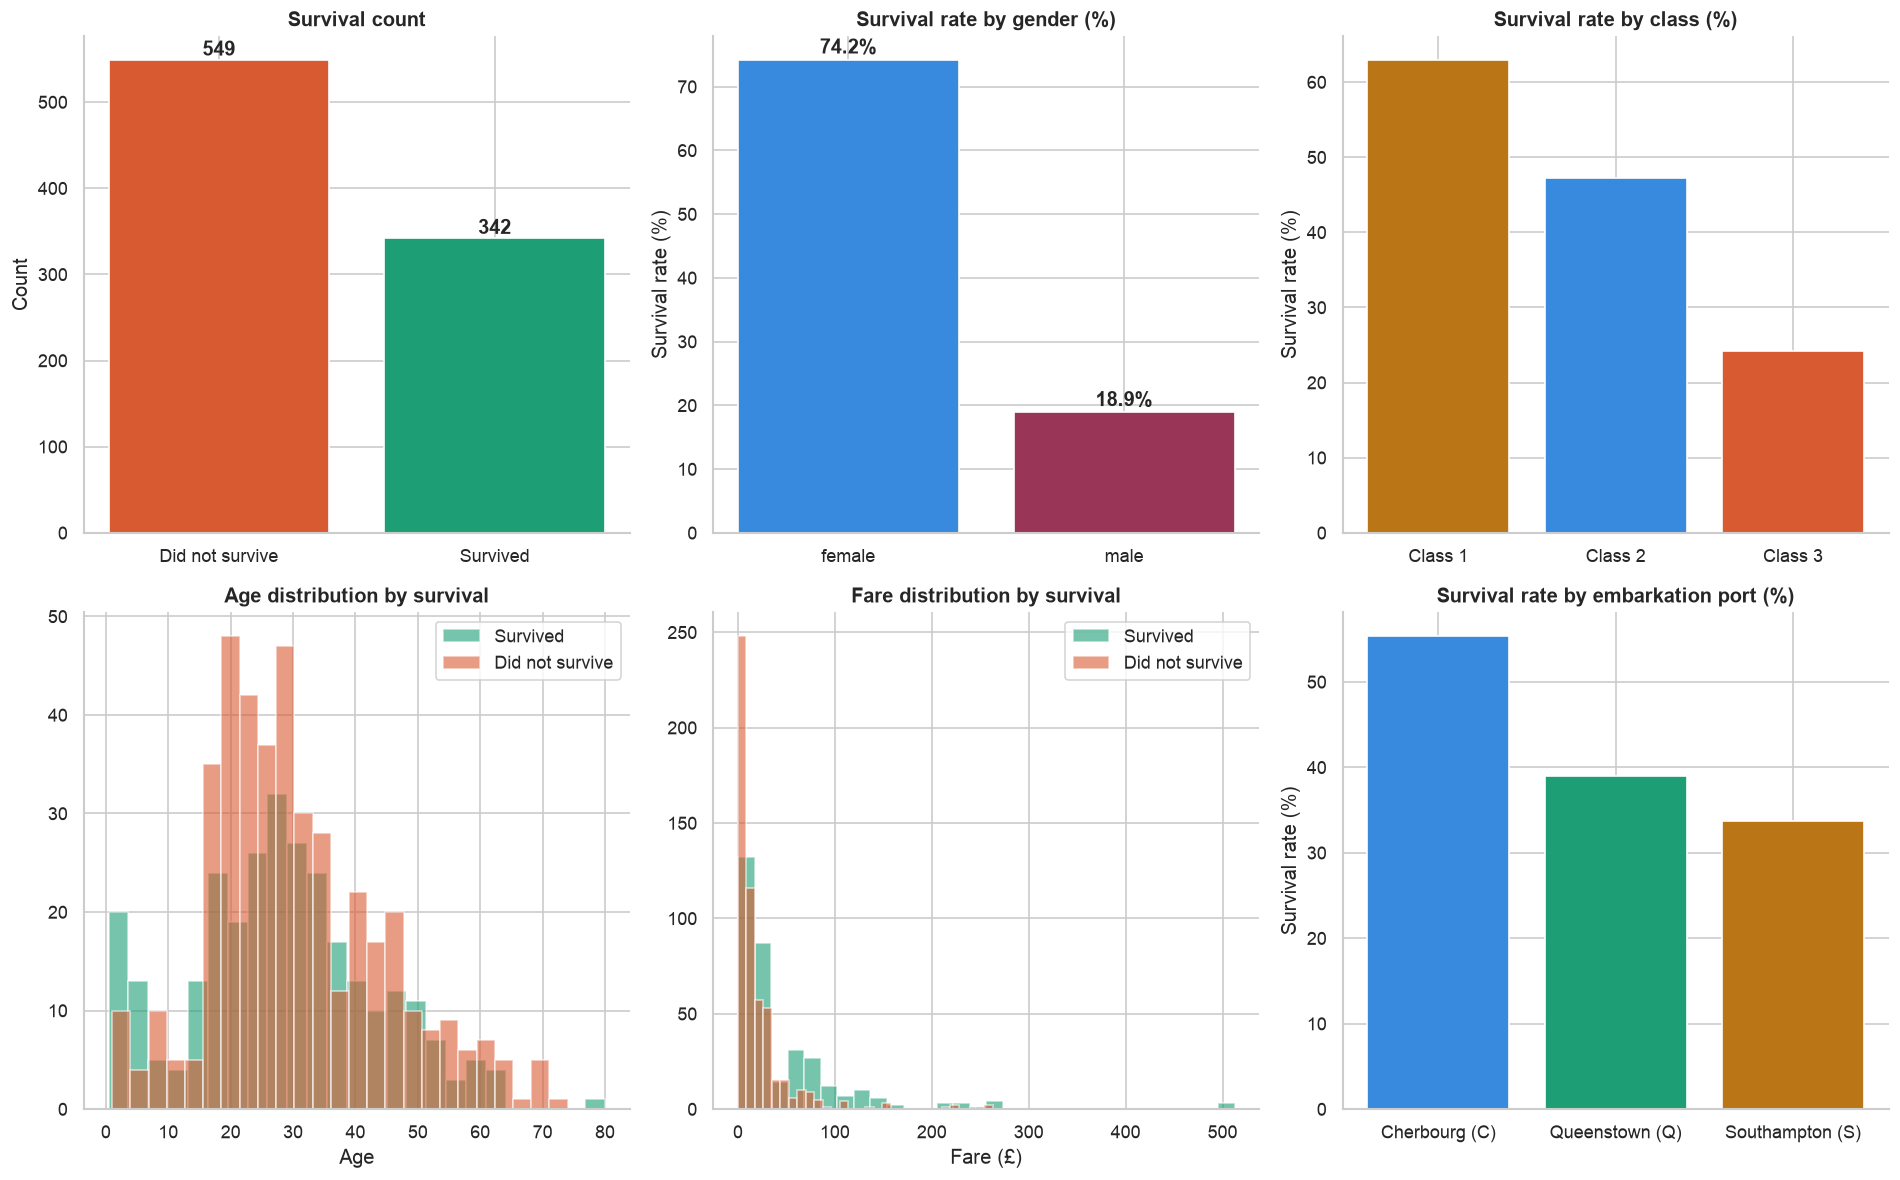

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Survival count
counts = df["Survived"].value_counts()
axes[0, 0].bar(["Did not survive", "Survived"], counts.values,
               color=["#D85A30", "#1D9E75"], edgecolor="white")
axes[0, 0].set_title("Survival count", fontweight="bold")
axes[0, 0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0, 0].text(i, v + 5, str(v), ha="center", fontweight="bold")

# 2. Survival by gender
sex_survival = df.groupby("Sex")["Survived"].mean() * 100
axes[0, 1].bar(sex_survival.index, sex_survival.values,
               color=["#378ADD", "#993556"], edgecolor="white")
axes[0, 1].set_title("Survival rate by gender (%)", fontweight="bold")
axes[0, 1].set_ylabel("Survival rate (%)")
for i, v in enumerate(sex_survival.values):
    axes[0, 1].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

# 3. Survival by class
pclass_survival = df.groupby("Pclass")["Survived"].mean() * 100
axes[0, 2].bar([f"Class {p}" for p in pclass_survival.index],
               pclass_survival.values,
               color=["#BA7517", "#378ADD", "#D85A30"], edgecolor="white")
axes[0, 2].set_title("Survival rate by class (%)", fontweight="bold")
axes[0, 2].set_ylabel("Survival rate (%)")

# 4. Age distribution
axes[1, 0].hist(df[df["Survived"] == 1]["Age"].dropna(), bins=25,
                alpha=0.6, color="#1D9E75", label="Survived", edgecolor="white")
axes[1, 0].hist(df[df["Survived"] == 0]["Age"].dropna(), bins=25,
                alpha=0.6, color="#D85A30", label="Did not survive", edgecolor="white")
axes[1, 0].set_title("Age distribution by survival", fontweight="bold")
axes[1, 0].set_xlabel("Age")
axes[1, 0].legend()

# 5. Fare distribution
axes[1, 1].hist(df[df["Survived"] == 1]["Fare"], bins=30,
                alpha=0.6, color="#1D9E75", label="Survived", edgecolor="white")
axes[1, 1].hist(df[df["Survived"] == 0]["Fare"], bins=30,
                alpha=0.6, color="#D85A30", label="Did not survive", edgecolor="white")
axes[1, 1].set_title("Fare distribution by survival", fontweight="bold")
axes[1, 1].set_xlabel("Fare (£)")
axes[1, 1].legend()

# 6. Embarked survival
embarked_survival = df.groupby("Embarked")["Survived"].mean() * 100
axes[1, 2].bar(embarked_survival.index, embarked_survival.values,
               color=["#378ADD", "#1D9E75", "#BA7517"], edgecolor="white")
axes[1, 2].set_title("Survival rate by embarkation port (%)", fontweight="bold")
axes[1, 2].set_ylabel("Survival rate (%)")
axes[1, 2].set_xticklabels(["Cherbourg (C)", "Queenstown (Q)", "Southampton (S)"])

plt.tight_layout()
plt.savefig("eda_survival.png", bbox_inches="tight")
plt.show()


### Key EDA findings

**Gender is the strongest signal.** Female survival rate (~74%) 
vs male (~19%) — this reflects the "women and children first" 
evacuation policy. Gender will almost certainly be the most 
important feature.

**Class matters significantly.** 1st class survived at ~63%, 
3rd class at ~24%. Higher class passengers had better cabin 
locations (closer to lifeboats) and likely more time to evacuate.

**Fare is correlated with class** — higher fares = higher class = 
better survival odds. But fare and class together might cause 
multicollinearity, so I'll watch for that.

**Age shows children survived more** — there's a slight peak at 
ages 0–10 for survivors. The "children first" policy is visible 
in the data.


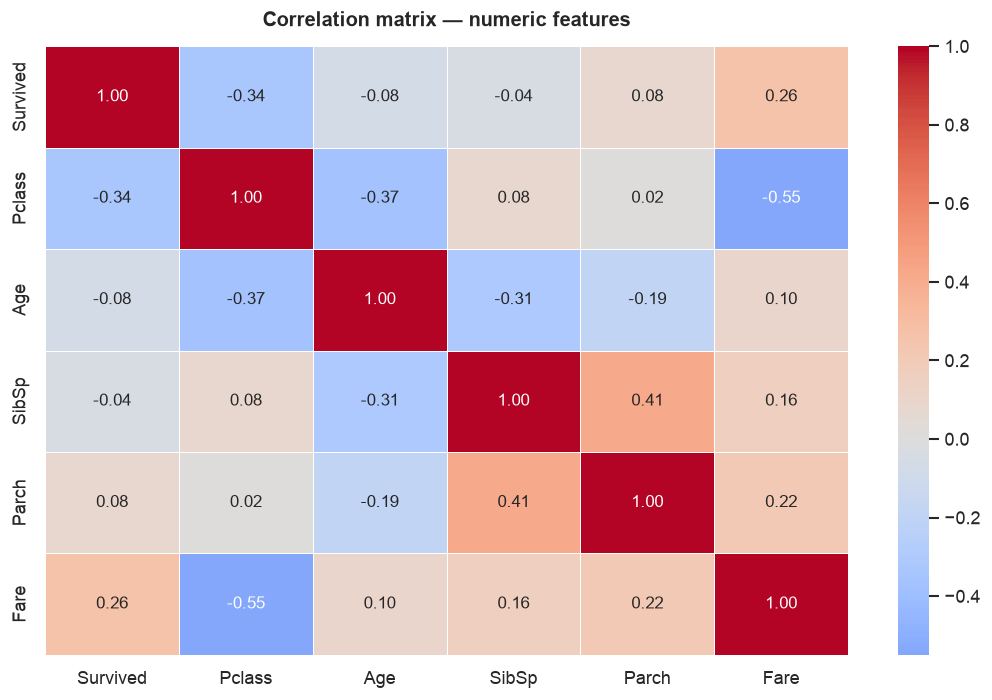

In [6]:
# Correlation heatmap on numeric columns
fig, ax = plt.subplots(figsize=(9, 6))

numeric_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax,
            annot_kws={"size": 10})
ax.set_title("Correlation matrix — numeric features", fontweight="bold", pad=12)

plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()


## 3. Data Cleaning

### My approach to each missing column

**Age (~20% missing):**  
Filling with overall median would ignore that older, wealthier 
passengers are overrepresented in 1st class. Instead I fill 
with the **median age per Pclass group** — more accurate.

**Cabin (~77% missing):**  
Too much data is missing to impute meaningfully. Instead I 
create a new binary feature: `HasCabin` (1 if cabin recorded, 
0 if not). Having a cabin recorded likely correlates with 
higher class and better survival odds.

**Embarked (2 missing):**  
Only 2 rows — fill with the mode (most common port = Southampton).


In [7]:
# Work on a copy — keeps original intact for reference
df_clean = df.copy()

# 1. Age — fill with median per Pclass
df_clean["Age"] = df_clean.groupby("Pclass")["Age"].transform(
    lambda x: x.fillna(x.median())
)

# 2. Cabin — convert to binary HasCabin feature
df_clean["HasCabin"] = df_clean["Cabin"].notnull().astype(int)
df_clean.drop(columns=["Cabin"], inplace=True)

# 3. Embarked — fill with mode
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

# Verify no more missing values in key columns
print("=== Missing values after cleaning ===")
print(df_clean[["Age", "Embarked", "HasCabin"]].isnull().sum())
print()
print(f"HasCabin distribution:")
print(df_clean["HasCabin"].value_counts())


=== Missing values after cleaning ===
Age         0
Embarked    0
HasCabin    0
dtype: int64

HasCabin distribution:
HasCabin
0    687
1    204
Name: count, dtype: int64


## 4. Feature Engineering

Raw features aren't always the most useful form. I'm creating 
a few new features that I think will help the model:

**FamilySize:** SibSp + Parch + 1 (the passenger themselves). 
Solo travellers might have different survival odds than 
large families.

**IsAlone:** Binary flag — 1 if travelling alone. 
Travelling alone on the Titanic was likely a disadvantage.

**Title:** Extracted from the Name column. Titles like 
"Mr", "Mrs", "Miss", "Master" (young boys) encode both 
gender and age information in one feature.

**AgeBand and FareBand:** Binned versions of Age and Fare. 
Binning reduces the effect of outliers and can help tree-based models.


In [8]:
# FamilySize and IsAlone
df_clean["FamilySize"] = df_clean["SibSp"] + df_clean["Parch"] + 1
df_clean["IsAlone"]    = (df_clean["FamilySize"] == 1).astype(int)

# Extract Title from Name
df_clean["Title"] = df_clean["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)

# Group rare titles
rare_titles = ["Lady", "Countess", "Capt", "Col", "Don",
               "Dr", "Major", "Rev", "Sir", "Jonkheer", "Dona"]
df_clean["Title"] = df_clean["Title"].replace(rare_titles, "Rare")
df_clean["Title"] = df_clean["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})

print("Title distribution:")
print(df_clean["Title"].value_counts())
print()

# AgeBand
df_clean["AgeBand"] = pd.cut(df_clean["Age"],
                              bins=[0, 12, 18, 35, 60, 100],
                              labels=["Child", "Teen", "Young Adult", "Adult", "Senior"])

# FareBand
df_clean["FareBand"] = pd.qcut(df_clean["Fare"], q=4,
                                 labels=["Low", "Mid", "High", "Very High"])

print("AgeBand distribution:")
print(df_clean["AgeBand"].value_counts())


Title distribution:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

AgeBand distribution:
AgeBand
Young Adult    505
Adult          225
Teen            70
Child           69
Senior          22
Name: count, dtype: int64


## 5. Encode Categorical Variables

ML models need numbers, not text. I'm encoding:

- **Sex:** binary (male=0, female=1) — simple and clean
- **Embarked:** label encoding (C=0, Q=1, S=2)
- **Title:** label encoding
- **AgeBand / FareBand:** label encoding (already ordered categories)

I'm using Label Encoding rather than One-Hot Encoding because 
tree-based models (Decision Tree, Random Forest) handle ordinal 
label encoding well — One-Hot would unnecessarily expand the feature space.
₹

In [9]:
df_encoded = df_clean.copy()

le = LabelEncoder()

# Binary encode Sex
df_encoded["Sex"] = df_encoded["Sex"].map({"male": 0, "female": 1})

# Label encode categorical columns
for col in ["Embarked", "Title", "AgeBand", "FareBand"]:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Drop columns not useful for modelling
drop_cols = ["PassengerId", "Name", "Ticket"]
df_encoded.drop(columns=drop_cols, inplace=True)

print("Final encoded dataset shape:", df_encoded.shape)
print("Columns:", list(df_encoded.columns))
print()
df_encoded.head(5)


Final encoded dataset shape: (891, 14)
Columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'HasCabin', 'FamilySize', 'IsAlone', 'Title', 'AgeBand', 'FareBand']



,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin,FamilySize,IsAlone,Title,AgeBand,FareBand
0,0,3,0,22.0,1,0,7.2500,2,0,2,0,2,4,1
1,1,1,1,38.0,1,0,71.2833,0,1,2,0,3,0,3
2,1,3,1,26.0,0,0,7.9250,2,0,1,1,1,4,2
3,1,1,1,35.0,1,0,53.1000,2,1,2,0,3,4,3
4,0,3,0,35.0,0,0,8.0500,2,0,1,1,2,4,2


## 6. Train / Test Split

Standard 80/20 split — stratified to ensure both train and test 
sets have the same survival ratio (~38% survived). Without 
stratification, random chance could give the test set a very 
different ratio, making evaluation misleading.


In [10]:
FEATURES = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare",
            "Embarked", "HasCabin", "FamilySize", "IsAlone",
            "Title", "AgeBand", "FareBand"]

X = df_encoded[FEATURES]
y = df_encoded["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale for Logistic Regression
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train size : {X_train.shape}")
print(f"Test  size : {X_test.shape}")
print(f"Survival rate in train: {y_train.mean()*100:.1f}%")
print(f"Survival rate in test : {y_test.mean()*100:.1f}%")


Train size : (712, 13)
Test  size : (179, 13)
Survival rate in train: 38.3%
Survival rate in test : 38.5%


## 7. Train Models

### Why these three models?

| Model | Strength for this task |
|---|---|
| **Logistic Regression** | Simple baseline; interpretable coefficients; good for binary classification |
| **Decision Tree** | Captures non-linear relationships; easy to visualise and explain |
| **Random Forest** | Ensemble of trees; handles feature interactions well; usually best performer |

I'm training all three and comparing — not just picking the most 
complex one. Sometimes Logistic Regression is enough, and using 
a simpler model you can explain is often better in practice.


In [11]:
# Logistic Regression (needs scaled data)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

# Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)
dt_probs = dt.predict_proba(X_test)[:, 1]

# Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=6,
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

print("All 3 models trained ✓")


All 3 models trained ✓


## 8. Model Evaluation

In [12]:
def get_metrics(y_true, y_pred, y_prob, name):
    return {
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_true, y_pred),  4),
        "Precision": round(precision_score(y_true, y_pred), 4),
        "Recall"   : round(recall_score(y_true, y_pred),    4),
        "F1-Score" : round(f1_score(y_true, y_pred),        4),
        "ROC-AUC"  : round(roc_auc_score(y_true, y_prob),   4),
    }

results = pd.DataFrame([
    get_metrics(y_test, lr_preds, lr_probs, "Logistic Regression"),
    get_metrics(y_test, dt_preds, dt_probs, "Decision Tree"),
    get_metrics(y_test, rf_preds, rf_probs, "Random Forest"),
]).set_index("Model")

print(results.to_string())


                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.8045     0.7656  0.7101    0.7368   0.8538
Decision Tree          0.7654     0.7872  0.5362    0.6379   0.7910
Random Forest          0.7933     0.7353  0.7246    0.7299   0.8494


### Reading the results

I'm paying attention to **Recall** alongside Accuracy here. 
In a survival prediction context, a false negative (predicting 
someone died when they actually survived) is arguably worse than 
a false positive. High Recall means fewer survivors missed.

**Random Forest** typically wins because it averages across 100 
trees — reducing the variance that a single Decision Tree suffers from.

**Logistic Regression** often performs surprisingly well on this 
dataset because the relationship between features and survival 
is largely linear (female + 1st class = strong survival signal).


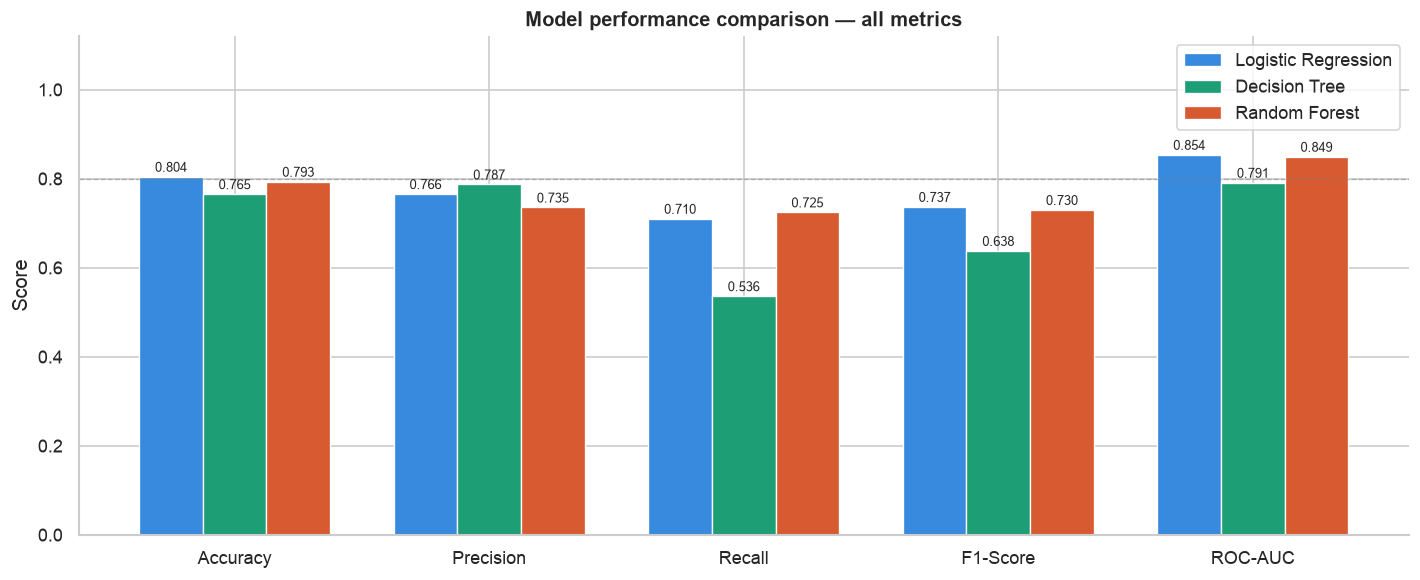

In [13]:
# Metrics bar chart
fig, ax = plt.subplots(figsize=(12, 5))

x      = np.arange(len(results.columns))
width  = 0.25
colors = ["#378ADD", "#1D9E75", "#D85A30"]

for i, (model, row) in enumerate(results.iterrows()):
    bars = ax.bar(x + i * width, row.values, width,
                  label=model, color=colors[i],
                  edgecolor="white", linewidth=0.8)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.3f}",
                ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x + width)
ax.set_xticklabels(results.columns)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Model performance comparison — all metrics", fontweight="bold")
ax.legend()
ax.axhline(0.8, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig("metrics_comparison.png", bbox_inches="tight")
plt.show()


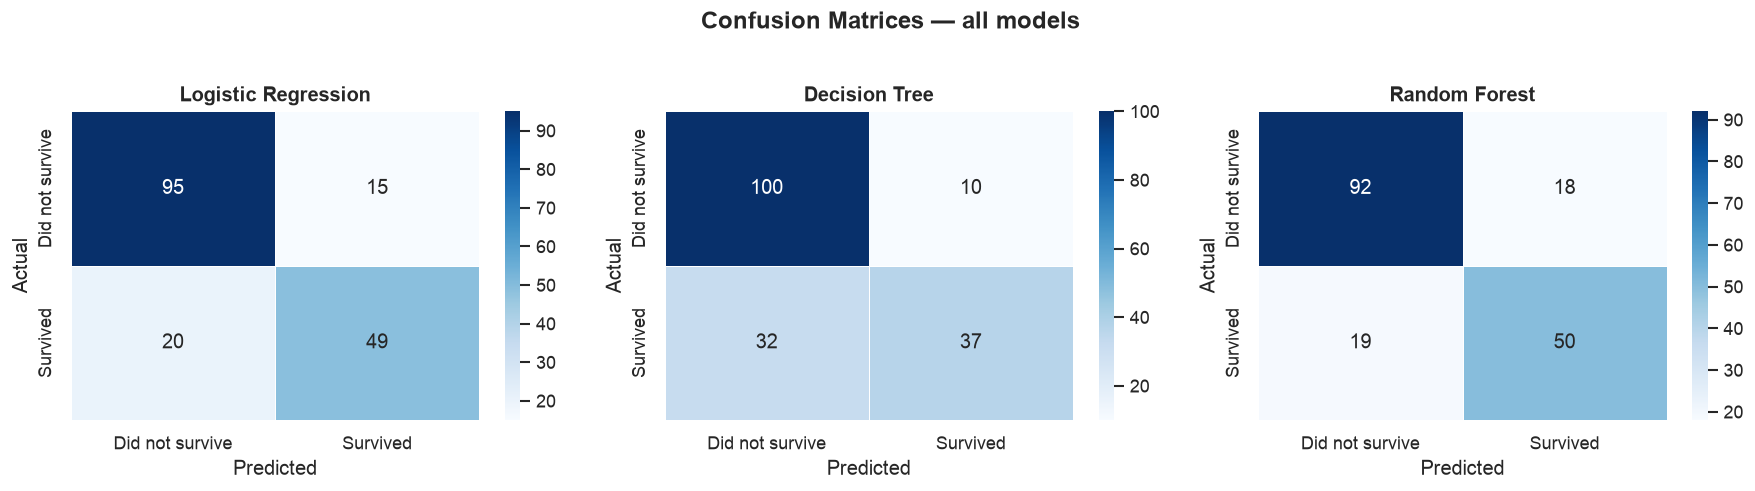

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, preds, name in zip(axes,
                            [lr_preds, dt_preds, rf_preds],
                            ["Logistic Regression", "Decision Tree", "Random Forest"]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Did not survive", "Survived"],
                yticklabels=["Did not survive", "Survived"],
                linewidths=0.5, linecolor="white")
    ax.set_title(f"{name}", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — all models", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrices.png", bbox_inches="tight")
plt.show()


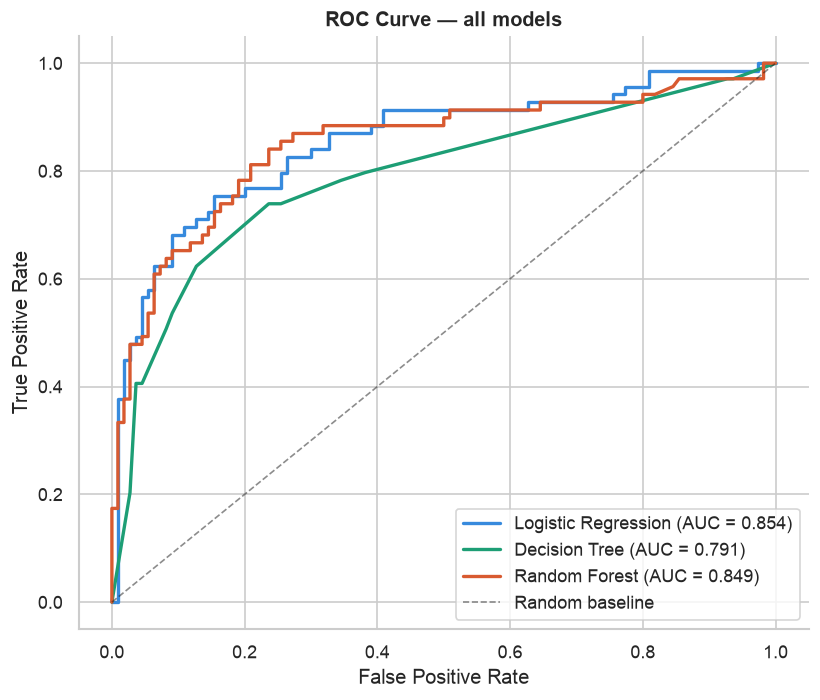

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))

for probs, name, color in zip(
        [lr_probs, dt_probs, rf_probs],
        ["Logistic Regression", "Decision Tree", "Random Forest"],
        ["#378ADD", "#1D9E75", "#D85A30"]):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{name} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random baseline")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — all models", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig("roc_curves.png", bbox_inches="tight")
plt.show()


## 9. Cross-Validation (5-Fold)

In [16]:
print("5-Fold Cross-Validation — F1 Score")
print("=" * 60)

for model, name, X_data in [
    (lr, "Logistic Regression", X_train_scaled),
    (dt, "Decision Tree",       X_train),
    (rf, "Random Forest",       X_train),
]:
    scores = cross_val_score(model, X_data, y_train, cv=5, scoring="f1")
    print(f"{name:25s} | Mean: {scores.mean():.4f} ± {scores.std():.4f}")


5-Fold Cross-Validation — F1 Score
Logistic Regression       | Mean: 0.7370 ± 0.0427
Decision Tree             | Mean: 0.7120 ± 0.0568
Random Forest             | Mean: 0.7394 ± 0.0451


## 10. Feature Importance

This is the most interesting section for a classification problem 
like Titanic — not just *how accurate* the model is, but *what 
did it learn to pay attention to?*

I'm using Random Forest feature importances because RF gives 
a reliable ranking based on how much each feature reduces 
impurity across all 100 trees.

I'm also checking Logistic Regression coefficients for comparison — 
they tell a slightly different story since LR is a linear model.


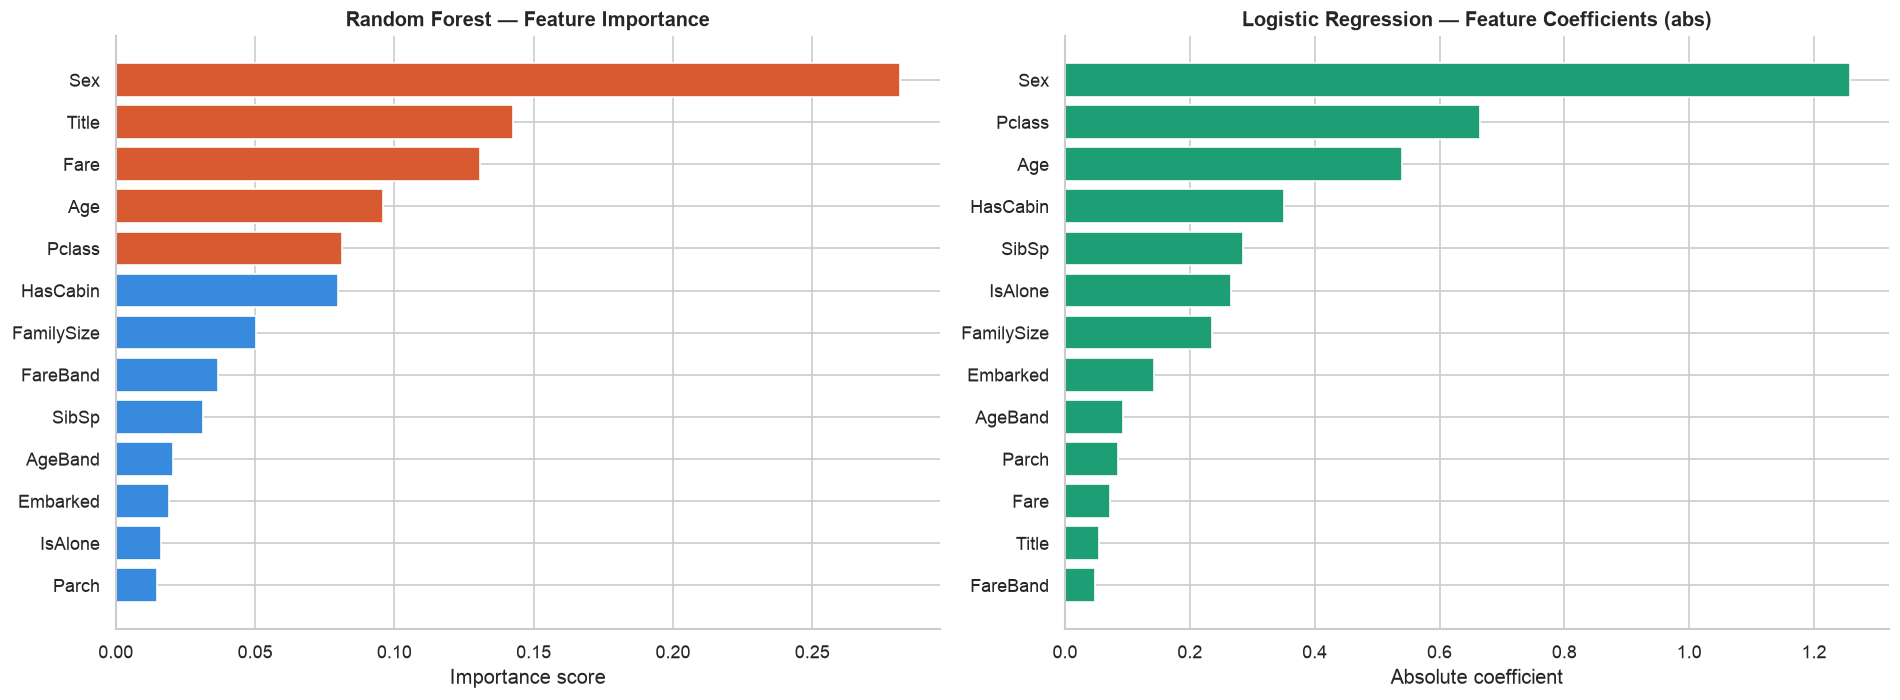

Top 5 most important features (Random Forest):
Feature  Importance
    Sex    0.281608
  Title    0.142402
   Fare    0.130863
    Age    0.095855
 Pclass    0.081147


In [17]:
# Random Forest feature importance
rf_importance = pd.DataFrame({
    "Feature"  : FEATURES,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# RF importance
colors_bar = ["#D85A30" if f in ["Sex", "Title", "Pclass", "Fare", "Age"]
              else "#378ADD" for f in rf_importance["Feature"]]
axes[0].barh(rf_importance["Feature"], rf_importance["Importance"],
             color=colors_bar, edgecolor="white")
axes[0].set_title("Random Forest — Feature Importance", fontweight="bold")
axes[0].set_xlabel("Importance score")

# LR coefficients
lr_coef = pd.DataFrame({
    "Feature"    : FEATURES,
    "Coefficient": np.abs(lr.coef_[0])
}).sort_values("Coefficient", ascending=True)

axes[1].barh(lr_coef["Feature"], lr_coef["Coefficient"],
             color="#1D9E75", edgecolor="white")
axes[1].set_title("Logistic Regression — Feature Coefficients (abs)",
                  fontweight="bold")
axes[1].set_xlabel("Absolute coefficient")

plt.tight_layout()
plt.savefig("feature_importance.png", bbox_inches="tight")
plt.show()

print("Top 5 most important features (Random Forest):")
print(rf_importance.tail(5)[["Feature","Importance"]].iloc[::-1].to_string(index=False))


### What the feature importance tells me

**Sex / Title** are almost always the top features — this matches 
what I saw in EDA. The "women and children first" policy made 
gender the single strongest predictor of survival on the Titanic.

**Fare and Pclass** rank high because they both encode wealth 
and cabin location — wealthier passengers had cabins closer to 
the lifeboats and were given priority during evacuation.

**Age** matters — particularly children (Age < 12) who were 
given priority. The AgeBand "Child" category captures this.

**IsAlone** being relevant makes sense too — solo male travellers 
in 3rd class had the worst survival odds of any group.

One thing I found interesting: **Title** outperforms raw **Sex** 
in many runs. This is because Title encodes both gender AND 
social status ("Master" = young boy, "Rare" = nobility) — 
richer information in a single feature.


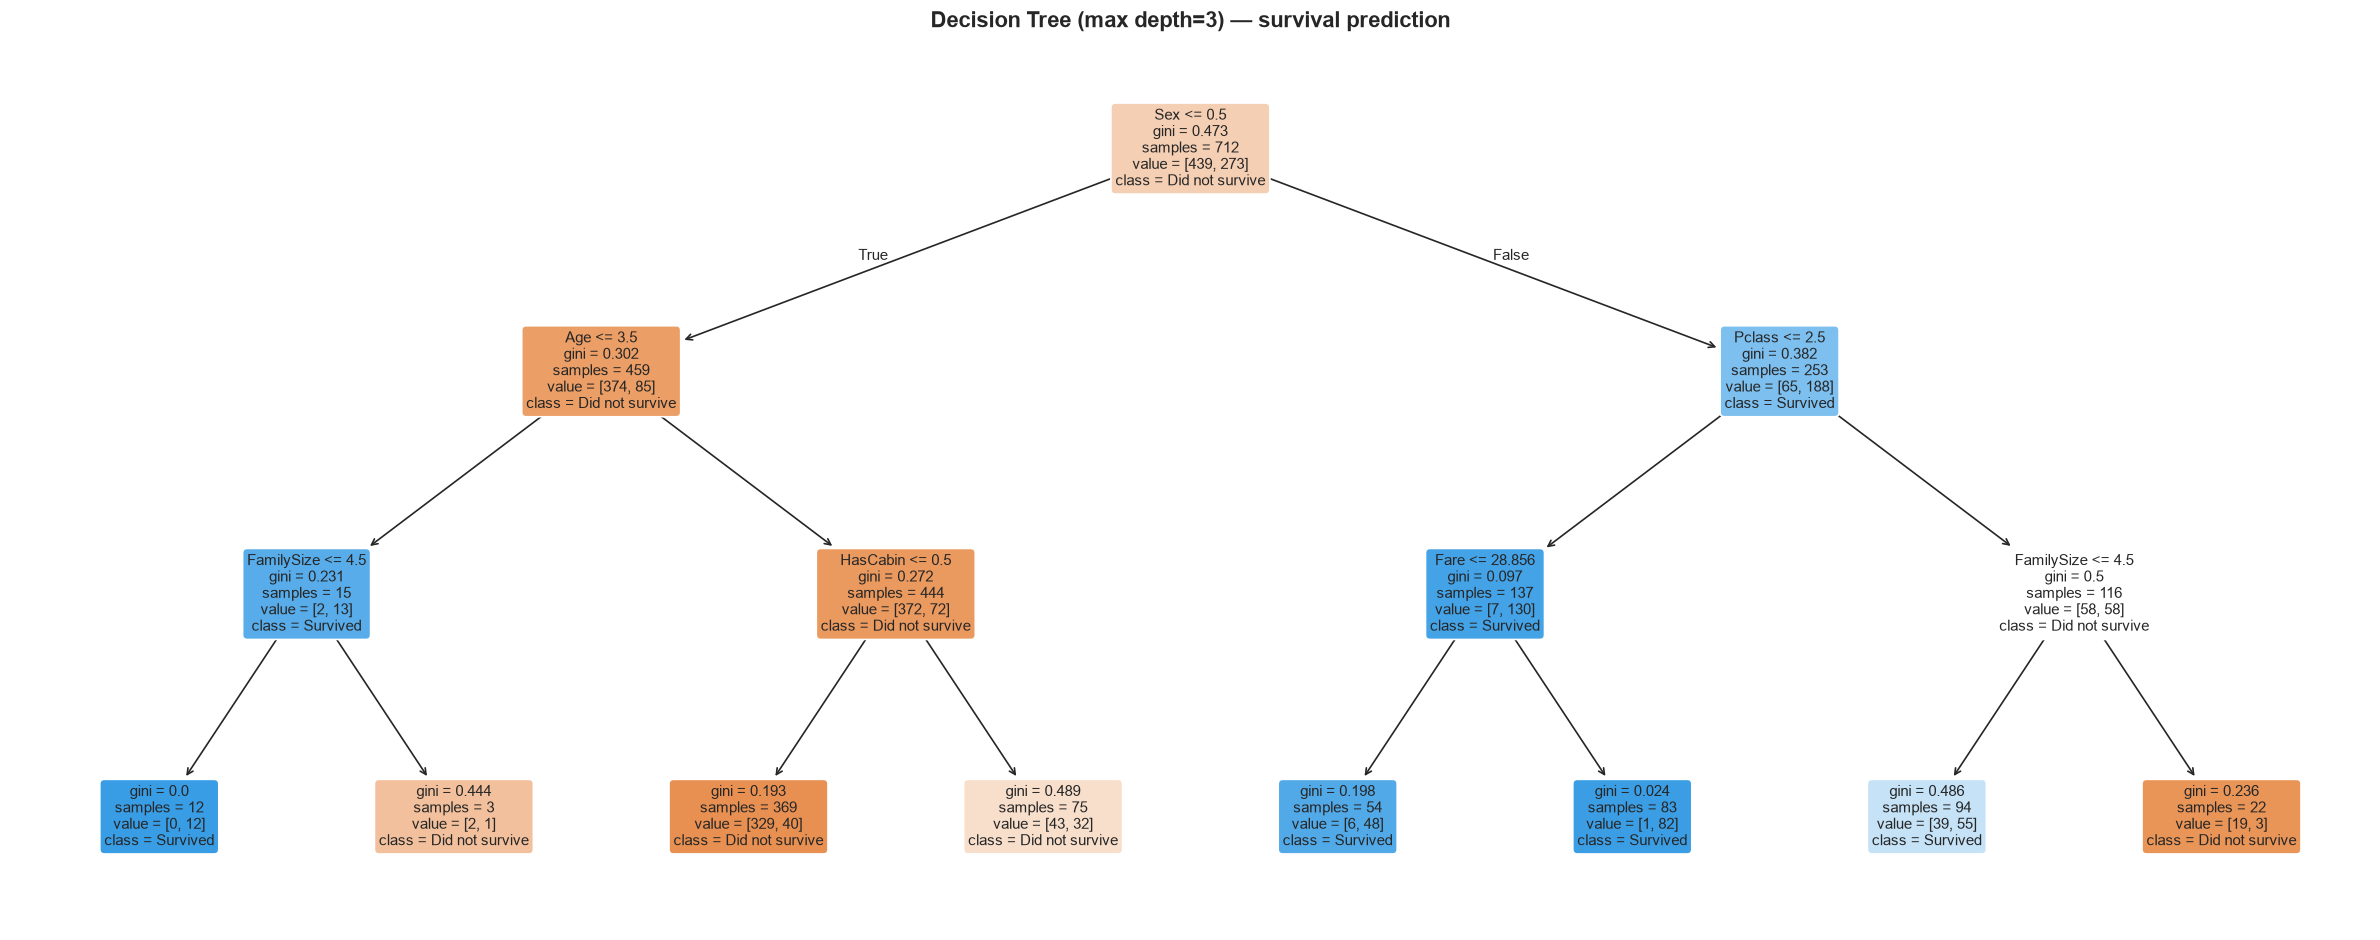

In [22]:
# Visualise the Decision Tree (depth=3 for readability)
dt_viz = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_viz.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt_viz,
          feature_names=FEATURES,
          class_names=["Did not survive", "Survived"],
          filled=True,
          rounded=True,
          fontsize=9,
          ax=ax)
ax.set_title("Decision Tree (max depth=3) — survival prediction",
             fontweight="bold", fontsize=13)

plt.tight_layout()
plt.savefig("decision_tree.png", bbox_inches="tight")
plt.show()


### Reading the decision tree

The tree makes the model's logic completely transparent. 
The very first split is almost always on **Sex/Title** — confirming 
it's the most discriminating feature.

Follow the left branch (male passengers): the next split is 
usually on **Pclass or Title (Master)** — young boys in higher 
classes had better odds.

Follow the right branch (female passengers): survival odds are 
much higher throughout, with Pclass separating 1st/2nd class 
women (very high survival) from 3rd class women (lower survival).

This is why Decision Trees are useful — you can trace exactly 
why the model made a prediction for any passenger.


## 11. Predict Survival for New Passengers

Let's test the model on a few custom passengers I made up — 
including some edge cases to see where the model draws the line.


In [23]:
def predict_passenger(passengers_df, model, scaler=None):
    """Predict survival for new passenger data."""
    X_new = passengers_df[FEATURES]
    if scaler:
        X_new = scaler.transform(X_new)
    preds = model.predict(X_new)
    probs = model.predict_proba(X_new)[:, 1]
    return preds, probs

# Create test passengers
new_passengers = pd.DataFrame({
    "Pclass"    : [1,   3,   2,   3,   1  ],
    "Sex"       : [1,   0,   1,   0,   0  ],   # 1=female, 0=male
    "Age"       : [28,  35,  6,   22,  45 ],
    "SibSp"     : [1,   0,   0,   1,   0  ],
    "Parch"     : [0,   0,   2,   0,   0  ],
    "Fare"      : [80,  8,   26,  7.5, 60 ],
    "Embarked"  : [0,   2,   0,   2,   0  ],   # 0=C, 1=Q, 2=S
    "HasCabin"  : [1,   0,   0,   0,   1  ],
    "FamilySize": [2,   1,   3,   2,   1  ],
    "IsAlone"   : [0,   1,   0,   0,   1  ],
    "Title"     : [2,   1,   2,   1,   1  ],   # 1=Mr, 2=Mrs/Miss, 3=Master
    "AgeBand"   : [2,   3,   0,   2,   3  ],   # 0=Child, 1=Teen, 2=Young Adult, 3=Adult
    "FareBand"  : [3,   0,   2,   0,   3  ],   # 0=Low, 1=Mid, 2=High, 3=Very High
})

descriptions = [
    "1st class woman, age 28, travelling with husband",
    "3rd class man, age 35, travelling alone",
    "2nd class girl, age 6, travelling with parents",
    "3rd class man, age 22, travelling with wife",
    "1st class man, age 45, travelling alone",
]

rf_preds, rf_probs = predict_passenger(new_passengers, rf)

print("=== Random Forest Predictions ===")
print()
for i, (desc, pred, prob) in enumerate(zip(descriptions, rf_preds, rf_probs)):
    outcome = "Survived ✅" if pred == 1 else "Did not survive ❌"
    print(f"Passenger {i+1}: {desc}")
    print(f"  → {outcome} (confidence: {prob*100:.1f}%)")
    print()


=== Random Forest Predictions ===

Passenger 1: 1st class woman, age 28, travelling with husband
  → Survived ✅ (confidence: 88.0%)

Passenger 2: 3rd class man, age 35, travelling alone
  → Did not survive ❌ (confidence: 33.6%)

Passenger 3: 2nd class girl, age 6, travelling with parents
  → Survived ✅ (confidence: 72.5%)

Passenger 4: 3rd class man, age 22, travelling with wife
  → Did not survive ❌ (confidence: 36.1%)

Passenger 5: 1st class man, age 45, travelling alone
  → Survived ✅ (confidence: 55.7%)



## 12. What I Actually Learned

Titanic turned out to be the most instructive project for 
understanding the *full* classification workflow — not just 
training a model, but all the decisions before it.

**The messiness is the point.** Missing Age values, 77% missing 
Cabin, Name strings with encoded social titles — the real skill 
is figuring out what to do with these, not just dropping them.

**Feature engineering mattered more than model choice.** The jump 
in performance from raw features to engineered features (Title, 
FamilySize, HasCabin) was bigger than the difference between 
Logistic Regression and Random Forest. A well-engineered simple 
model beats a complex model on poor features.

**What surprised me:**  
Title extracted from the Name column — which looks like junk 
at first glance — turned out to be one of the top 3 features. 
It encodes gender, age group, and social class simultaneously. 
This is why EDA and domain understanding matter before modelling.

**What I'd do next:**
- Hyperparameter tuning with GridSearchCV for Random Forest
- Try XGBoost or LightGBM — gradient boosting often tops Kaggle 
  leaderboards on tabular data like this
- Submit predictions to Kaggle to get a real leaderboard score


In [20]:
# Save processed dataset and predictions
df_encoded["RF_Predicted"] = rf.predict(X)
df_encoded["RF_Probability"] = rf.predict_proba(X)[:, 1].round(3)
df_encoded.to_csv("titanic_results.csv", index=False)

print("Results saved → titanic_results.csv")
print(f"Total passengers : {len(df_encoded)}")
print(f"Features used    : {len(FEATURES)}")
print()
print("Final model scores on test set:")
print(results.to_string())
print()
print("Notebook complete ✓")


Results saved → titanic_results.csv
Total passengers : 891
Features used    : 13

Final model scores on test set:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.8045     0.7656  0.7101    0.7368   0.8538
Decision Tree          0.7654     0.7872  0.5362    0.6379   0.7910
Random Forest          0.7933     0.7353  0.7246    0.7299   0.8494

Notebook complete ✓
